# Unblinded búsqueda

In [1]:
!pip install -U "huggingface_hub>=1.3.0"
!pip install sam3
!pip install fastapi nest-asyncio pyngrok uvicorn python-multipart

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 13.4 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=789afea79b1feb689f400eedfa36bd9da8bcc2c9f86a859c69eda8c2861236ab
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built iopath


In [2]:
import huggingface_hub
import transformers
import sam3
import requests
from PIL import Image
from io import BytesIO
import torch
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
import os
import requests
from google.colab import userdata
from huggingface_hub import login
import numpy as np
from google.colab import files
import matplotlib

In [3]:
import nest_asyncio
from fastapi import FastAPI, Response
from pyngrok import ngrok
import uvicorn
import cv2
import numpy as np
import io

### Funciones de SAM3

In [4]:
def ImageToImage(img, prompt):
  # 1. Definimos la ruta que el error reclama
  target_dir = "/usr/local/lib/python3.12/dist-packages/assets/"
  target_file = os.path.join(target_dir, "bpe_simple_vocab_16e6.txt.gz")

  # 2. Creamos el directorio si no existe
  !sudo mkdir -p {target_dir}
  !sudo chmod 777 {target_dir}

  # 3. Descargamos el archivo que falta
  url = "https://github.com/openai/CLIP/raw/main/clip/bpe_simple_vocab_16e6.txt.gz"

  response = requests.get(url)
  with open(target_file, "wb") as f:
      f.write(response.content)

  # Load the model
  model = build_sam3_image_model()
  processor = Sam3Processor(model)

  inference_state = processor.set_image(image)
  # Prompt the model with text

  output = processor.set_text_prompt(state=inference_state, prompt=prompt)

  # Get the masks, bounding boxes, and scores
  masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

  return masks

In [5]:
def overlay_masks(image, masks):
    image = image.convert("RGBA")
    # Pasamos a numpy y aseguramos tipo uint8
    masks_np = masks.cpu().numpy().astype(np.uint8)

    # Si masks tiene una dimensión extra vacía (ej. 1, H, W), la eliminamos
    if masks_np.ndim == 4: # Caso [N, 1, H, W]
        masks_np = np.squeeze(masks_np, axis=1)

    n_masks = masks_np.shape[0]
    cmap = matplotlib.colormaps.get_cmap("rainbow").resampled(n_masks)

    for i in range(n_masks):
        mask_2d = masks_np[i]
        # Si por alguna razón sigue siendo (1, H, W), forzamos (H, W)
        if mask_2d.ndim == 3:
            mask_2d = mask_2d.squeeze()

        color = tuple(int(c * 255) for c in cmap(i)[:3])

        # Crear la máscara de Pillow
        mask_img = Image.fromarray(mask_2d)

        # Crear capa de color
        overlay = Image.new("RGBA", image.size, color + (0,))

        # Definir transparencia (alpha): donde hay máscara, 50% de opacidad (127)
        alpha = mask_img.point(lambda v: 127 if v > 0 else 0)
        overlay.putalpha(alpha)

        # Combinar
        image = Image.alpha_composite(image, overlay)

    return image

### Llamada al modo búsqueda

In [6]:
# Esto lee el secreto que configuraste en el panel de la izquierda
token = userdata.get('HF_TOKEN')
login(token=token)

In [7]:
# Obtención de la imagen
img_path = "praderas.jpg"
image = Image.open(img_path).convert("RGB")
prompt = 'head'

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

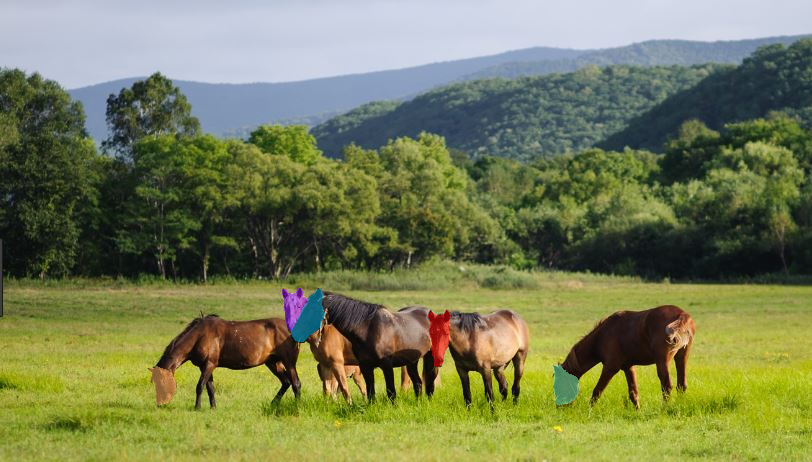

In [8]:
masks = ImageToImage(image, prompt)

new_img = overlay_masks(image, masks)
new_img

In [9]:
img_path = os.path.join("sample_data", "new_img.png")
new_img.save(img_path)

In [10]:
files.download(img_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>